In [2]:
import tensorflow as tf                                      # Imports the Tensorflow library for building and training neural networks
from tensorflow import keras                                 # Imports Keras API from Tensorflow
# Print installed version of the library
print(tf.__version__)              
print(keras.__version__)
# Import all necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

2.19.0
3.10.0


In [3]:
from sklearn.model_selection import train_test_split        # For splitting dataset into train and test parts
from sklearn.preprocessing import StandardScaler            # For normalizing numerical features

# from google.colab import files
# uploaded = files.upload()

In [4]:
# import io
housing=pd.read_csv('housing.csv')         # Reads uploaded Excel File
housing                                    # Displays the loaded data in notebook 

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100,INLAND
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100,INLAND
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300,INLAND
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700,INLAND


In [5]:
housing.pop('ocean_proximity')  # Removes categorical column (non-numeric) not yet encoded
housing.pop('total_bedrooms')   # Removes'total_bedrooms' column (maybe due to missing values

0         129.0
1        1106.0
2         190.0
3         235.0
4         280.0
          ...  
20635     374.0
20636     150.0
20637     485.0
20638     409.0
20639     616.0
Name: total_bedrooms, Length: 20640, dtype: float64

In [6]:
# hnorm=(((housing-housing.min())/(housing.max()-housing.min())))
# hnorm.isna().sum()

# Using Min Max Scalar
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Select only numeric columns for normalization
numeric_cols = housing.select_dtypes(include='number').columns
scaler = MinMaxScaler()  # Initialize Min-Max Scaler (scales values between 0 and 1)

hnorm = pd.DataFrame(scaler.fit_transform(housing[numeric_cols]), columns=numeric_cols)  # Transform numeric data & keep column names
hnorm.isna().sum()       # Check if any NaN values remain after scaling

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64

In [7]:
housing.dtypes

longitude             float64
latitude              float64
housing_median_age      int64
total_rooms             int64
population              int64
households              int64
median_income         float64
median_house_value      int64
dtype: object

In [8]:
housing.total_rooms

0         880
1        7099
2        1467
3        1274
4        1627
         ... 
20635    1665
20636     697
20637    2254
20638    1860
20639    2785
Name: total_rooms, Length: 20640, dtype: int64

In [9]:
target = housing.pop('median_house_value')  # Remove target column from dataset and store it separately

In [10]:
Y = target.values                           # Target values as NumPy array
X = hnorm.values                            # Features as normalized NumPy array
X

array([[0.21115538, 0.5674814 , 0.78431373, ..., 0.02055583, 0.53966842,
        0.90226638],
       [0.21215139, 0.565356  , 0.39215686, ..., 0.18697583, 0.53802706,
        0.70824656],
       [0.21015936, 0.5642933 , 1.        , ..., 0.02894261, 0.46602805,
        0.69505074],
       ...,
       [0.31175299, 0.73219979, 0.31372549, ..., 0.07104095, 0.08276438,
        0.15938285],
       [0.30179283, 0.73219979, 0.33333333, ..., 0.05722743, 0.09429525,
        0.14371281],
       [0.30976096, 0.72582359, 0.29411765, ..., 0.08699227, 0.13025338,
        0.15340349]])

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, Y,test_size=0.15)    # 85% train, 15% test
y_train.shape

# Create a separate validation set from the tail of training data
x_val=X_train[16000:]
y_val=y_train[16000:]
X_train=X_train[:16000]
y_train=y_train[:16000]

In [18]:
model = keras.models.Sequential([
keras.layers.Dense(128, activation="relu",input_shape=(8,)),     # Input layer: 8 features, Hidden: 128 neurons, ReLU activation
#keras.layers.Dense(16, activation="relu"),
keras.layers.Dense(1)])                                          # Output layer: predicts one continuous value

model.compile(loss="mae", optimizer="sgd")                       # loss = Mean Absolute Error, optimizer = Stochastic Gradient Descent
# Train 50 epochs and show its progress, use validation set to track overfitting
history = model.fit(X_train, y_train, epochs=50,verbose=1,validation_data=(x_val, y_val))

"""
model = keras.Sequential([keras.Input(shape=(X_train.shape[8],)), keras.layers.Dense(32, activation="relu"), keras.layers.Dense(16, activation="relu"),
keras.layers.Dense(1)])
model.compile(loss="mae", optimizer="adam", metrics=["mae"])
history = model.fit(X_train, y_train, epochs=20, validation_split=0.2, callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)], verbose=1)
"""

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 205549.7656 - val_loss: 80124.0234
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 73223.2891 - val_loss: 40130.0273
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 24827.6836 - val_loss: 4875.8325
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 4386.5874 - val_loss: 4481.4619
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 4599.1436 - val_loss: 4734.4951
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 4449.3281 - val_loss: 4230.1675
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 4434.0225 - val_loss: 4145.8203
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 4291.2935 - val_loss: 4109.1382
Epoch 9/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 4190.6611 - val_loss: 3604.9695
Epoch 10/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 4083.1370 - val_loss: 3651.8152
Epoch 11/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 4066.5012 - 

'\nmodel = keras.Sequential([keras.Input(shape=(X_train.shape[8],)), keras.layers.Dense(32, activation="relu"), keras.layers.Dense(16, activation="relu"),\nkeras.layers.Dense(1)])\nmodel.compile(loss="mae", optimizer="adam", metrics=["mae"])\nhistory = model.fit(X_train, y_train, epochs=20, validation_split=0.2, callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)], verbose=1)\n'

In [19]:
history_dict = history.history    # Dictionary containing loss values
history_dict.keys()

dict_keys(['loss', 'val_loss'])

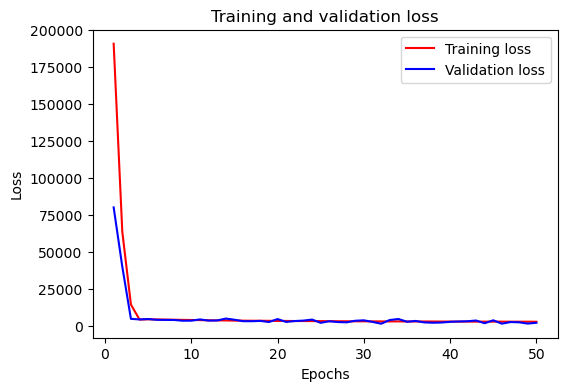

In [20]:
history_dict = history.history              # Dictionary containing loss values
loss_values = history_dict['loss']          # Training loss per epoch
val_loss_values = history_dict['val_loss']  # Validation loss per epoch
#acc = history_dict['accuracy']
epochs = range(1, len(loss_values)+1 )
plt.figure(figsize=(6, 4))
#plt.subplot(121)
plt.plot(epochs, loss_values, 'r', label='Training loss')        # Red line: training error over epochs
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')  # Blue line: validation error
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()



In [21]:
htest = model.evaluate(X_test, y_test)   # Get MAE on unseen test set

97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2235.9414


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


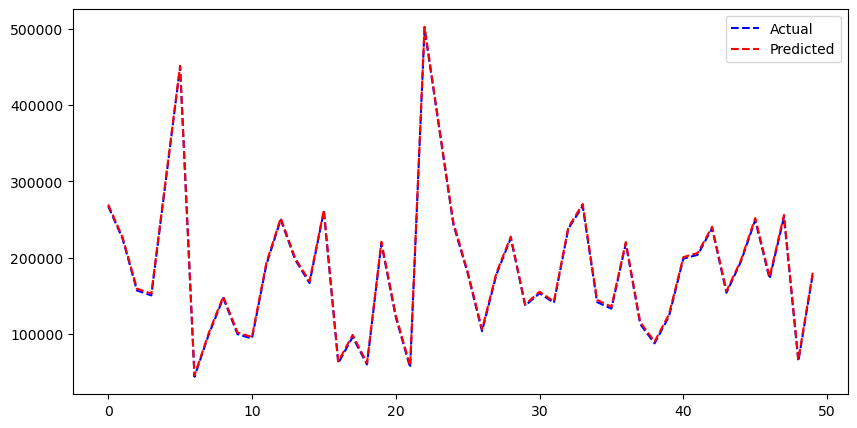

In [22]:
# Pretend these are new instances
X_new = X_test[:50]                      # Select first 50 samples from test set
y_pred = model.predict(X_new)            # Model predictions

plt.figure(figsize=(10,5))
plt.plot(np.arange(0,len(X_new),1), y_test[:50], 'b--', label='Actual')   # Blue = true prices
plt.plot(np.arange(0,len(X_new),1), y_pred, 'r--', label='Predicted')     # Red = predictions
plt.legend()
plt.show()
#plt.scatter(y_test[:20],y_pred)

[0.9994418]


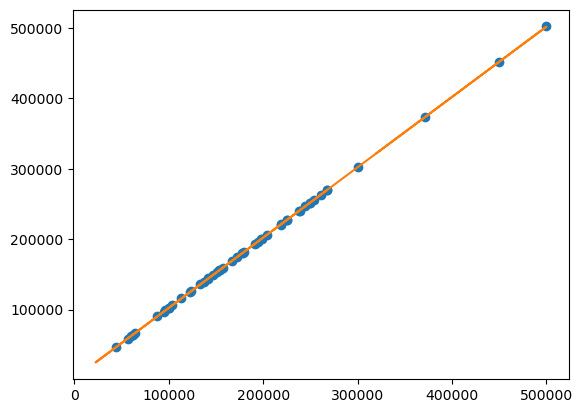

In [23]:
X_new = X_test[:50]
plt.plot(y_test[:50], y_pred, 'o')              # Scatter: (Actual, Predicted)
m, b = np.polyfit(y_test[:50], y_pred, 1)       # Fit straight line to predictions
plt.plot(y_test, m*y_test + b)                  # Plot trend line
print(m)                                        # Print slope (closer to 1 is better)